# Crop Recommendation Model
### AgriSense — IoT & AI Based Smart Crop and Fertilizer Recommendation System
**Team:** Kushal | Akarshan Poudel | Sachin Kandel | Sushovan Bikram Shahi

---
**Input Sources:**
| Feature | Source |
|---|---|
| N, P, K | Manually entered in UI |
| Temperature, Humidity | DHT22 Sensor (ESP32) |
| pH | pH Sensor (ESP32) |
| Rainfall | Manually entered in UI |

**Output:** Recommended crop name


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay)
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 5)
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

In [4]:
df = pd.read_csv("Crop_recommendation.csv")
print("Shape:", df.shape)
df.head(10)

Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


## 3. Exploratory Data Analysis (EDA)

### 3.1 Basic Info

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [6]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


### 3.2 Missing Values & Duplicates

In [9]:
print("Missing values:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate rows: 0


### 3.3 Class Distribution — Samples per Crop

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


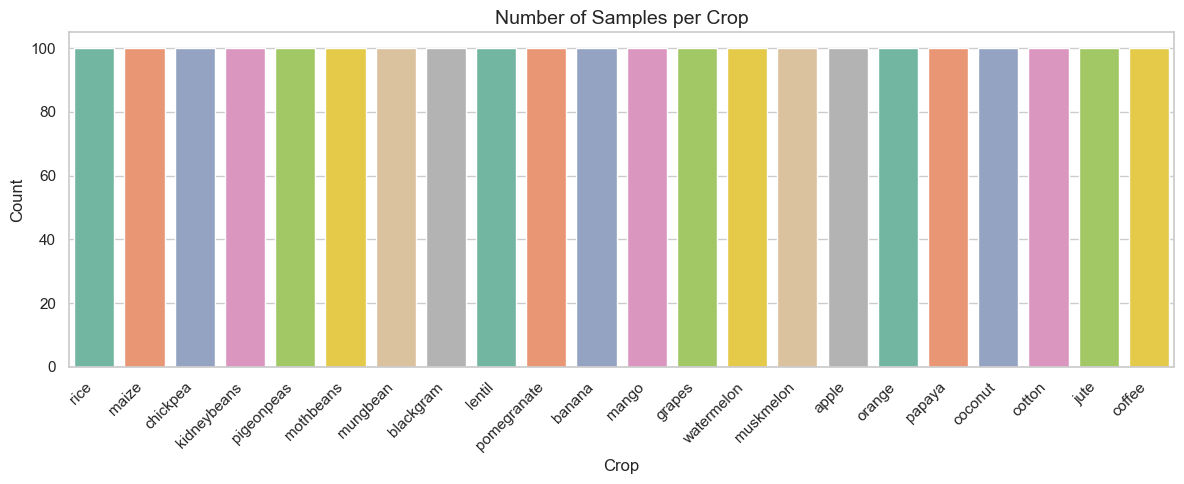

In [10]:
counts = df['label'].value_counts()
print(counts)

plt.figure(figsize=(12, 5))
sns.barplot(x=counts.index, y=counts.values, palette="Set2")
plt.title("Number of Samples per Crop", fontsize=14)
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.4 Feature Distributions — Histograms

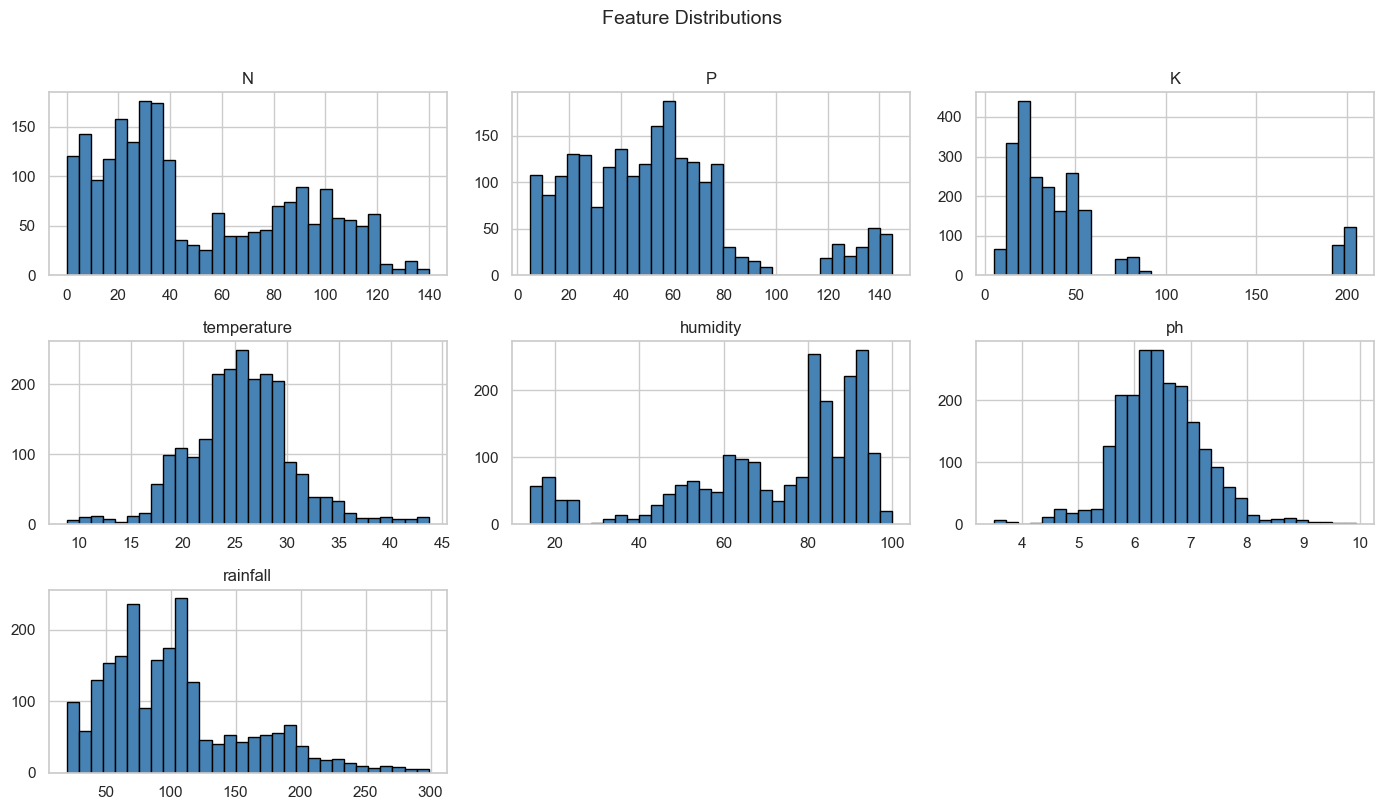

In [11]:
df.drop(columns=['label']).hist(bins=30, figsize=(14, 8), color='steelblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.5 Boxplots — Checking for Outliers

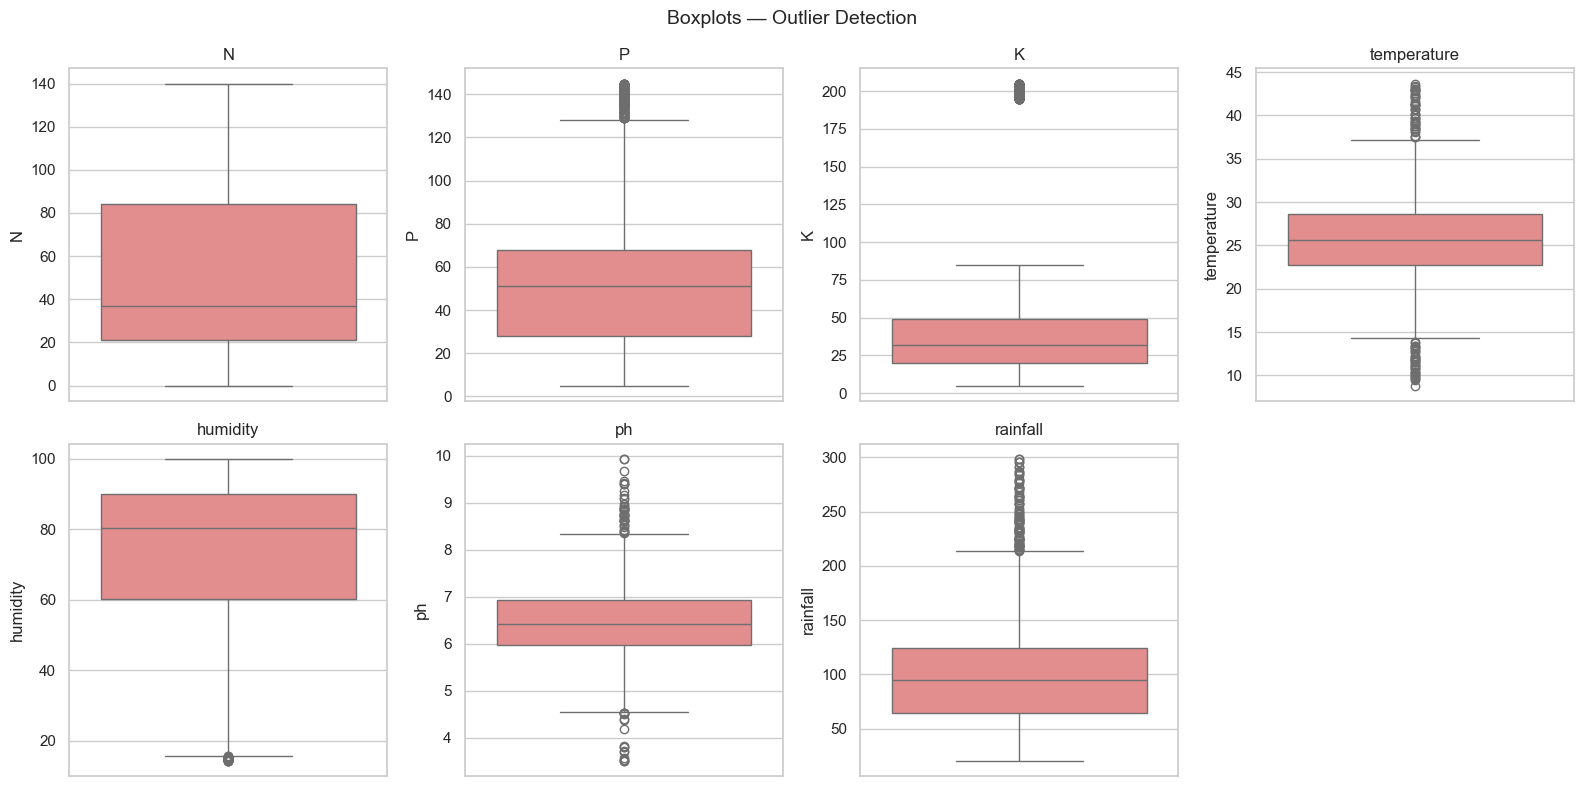

In [14]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, col in enumerate(features):
    ax = axes[i // 4][i % 4]
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(col)

axes[1][3].set_visible(False)
plt.suptitle("Boxplots — Outlier Detection", fontsize=14)
plt.tight_layout()
plt.show()

### 3.6 Correlation Heatmap

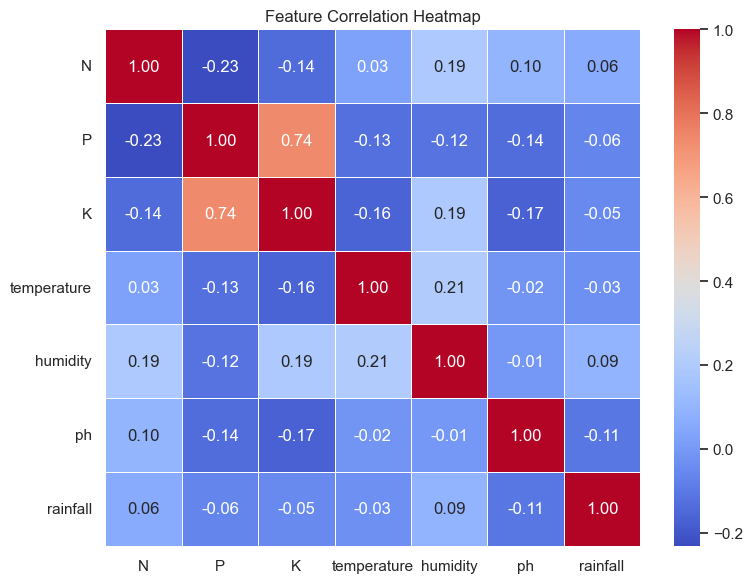

In [12]:
plt.figure(figsize=(8, 6))
corr = df.drop(columns=['label']).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### 3.7 Average Feature Value per Crop

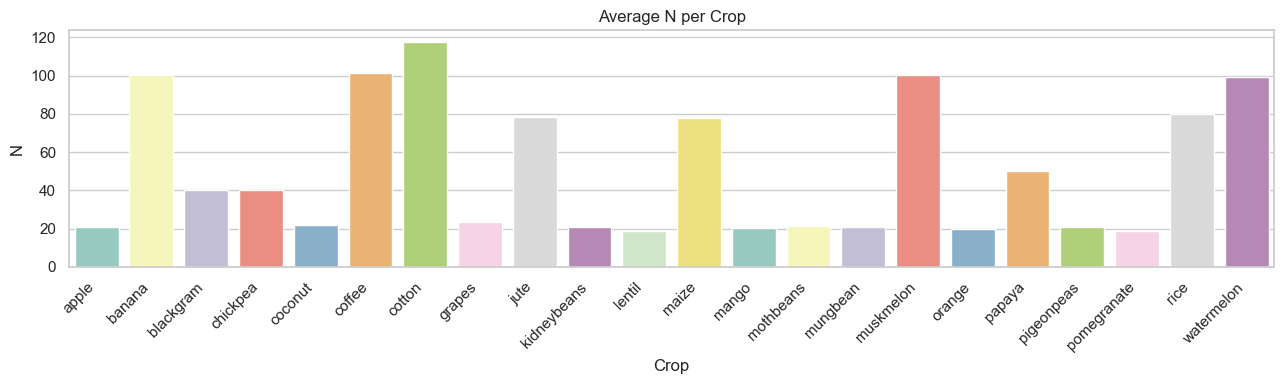

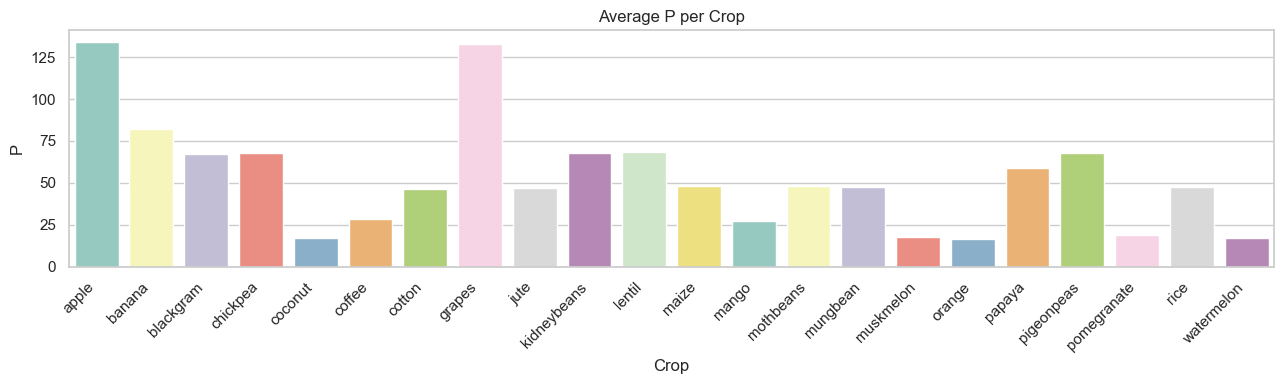

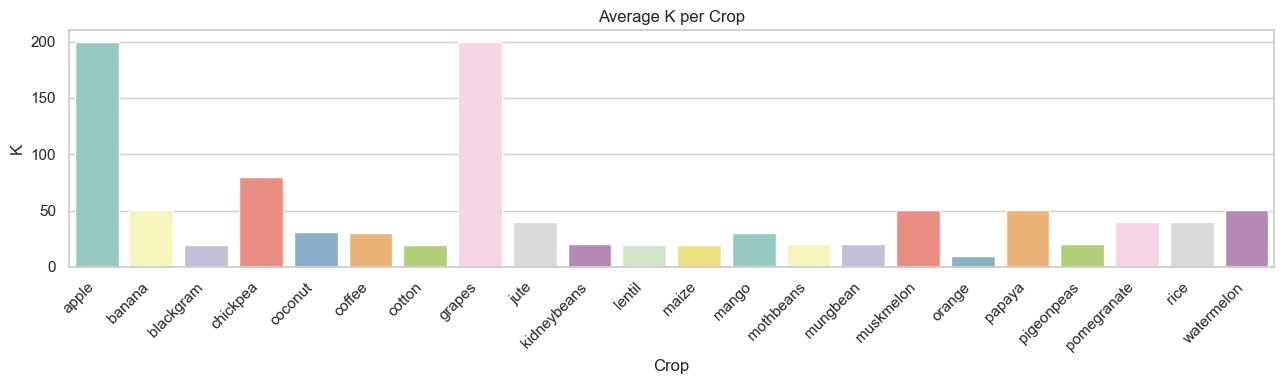

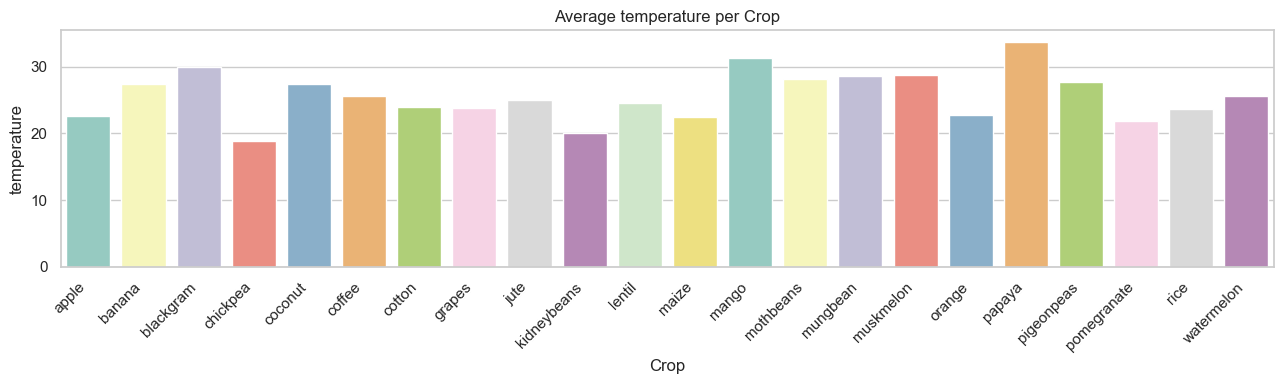

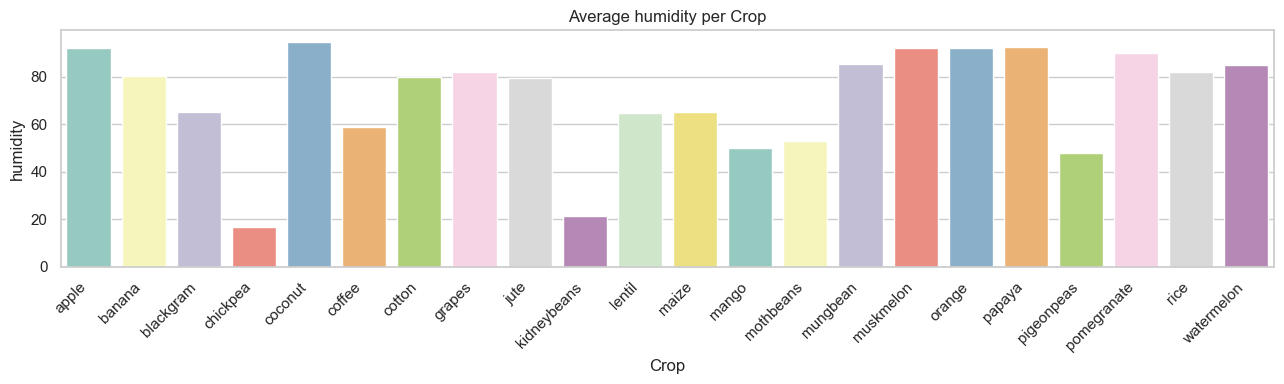

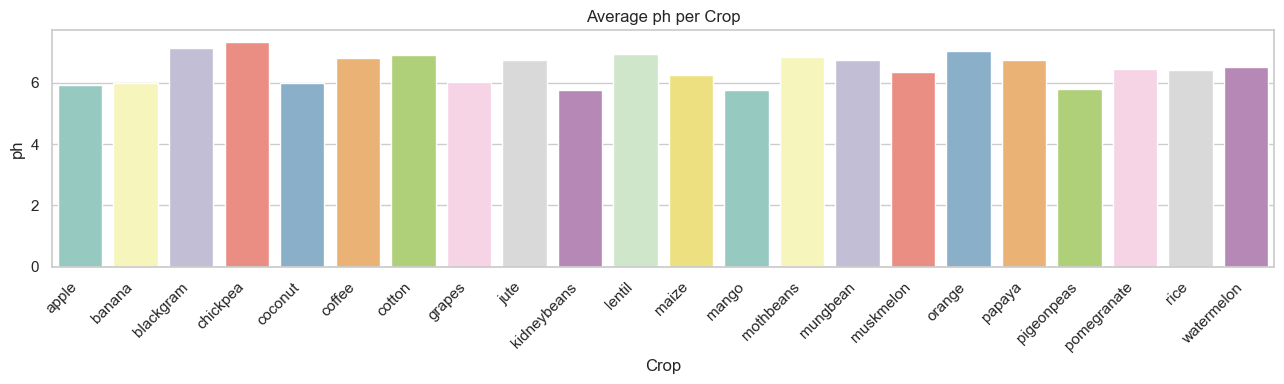

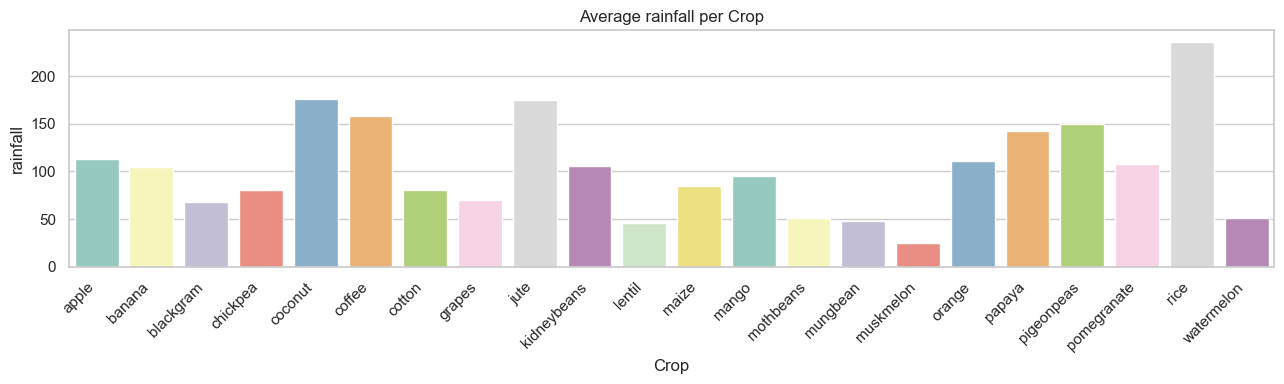

In [15]:
crop_mean = df.groupby('label').mean().reset_index()

for col in features:
    plt.figure(figsize=(13, 4))
    sns.barplot(data=crop_mean, x='label', y=col, palette='Set3')
    plt.title(f"Average {col} per Crop")
    plt.xlabel("Crop")
    plt.ylabel(col)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 4. Preprocessing

### 4.1 Encode Target Label

In [17]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

print("Crop label encoding:")
for i, name in enumerate(le.classes_):
    print(f"  {i:2d}  →  {name}")

Crop label encoding:
   0  →  apple
   1  →  banana
   2  →  blackgram
   3  →  chickpea
   4  →  coconut
   5  →  coffee
   6  →  cotton
   7  →  grapes
   8  →  jute
   9  →  kidneybeans
  10  →  lentil
  11  →  maize
  12  →  mango
  13  →  mothbeans
  14  →  mungbean
  15  →  muskmelon
  16  →  orange
  17  →  papaya
  18  →  pigeonpeas
  19  →  pomegranate
  20  →  rice
  21  →  watermelon


### 4.2 Define Features (X) and Target (y)

In [18]:
X = df[features]
y = df['label_enc']

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (2200, 7)
y shape: (2200,)


,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


### 4.3 Train / Test Split — 80% train, 20% test

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape[0])
print("Test  size:", X_test.shape[0])

Train size: 1760
Test  size: 440


## 5. Model Training — Random Forest

In [20]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

pipeline.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


## 6. Evaluation

### 6.1 Accuracy

In [21]:
y_pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy  : {acc * 100:.2f}%")

cv = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
print(f"5-Fold CV Mean : {cv.mean()*100:.2f}%")
print(f"5-Fold CV Std  : {cv.std()*100:.2f}%")

Test Accuracy  : 99.55%
5-Fold CV Mean : 99.50%
5-Fold CV Std  : 0.36%


### 6.2 Classification Report

In [ ]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

### 6.3 Confusion Matrix

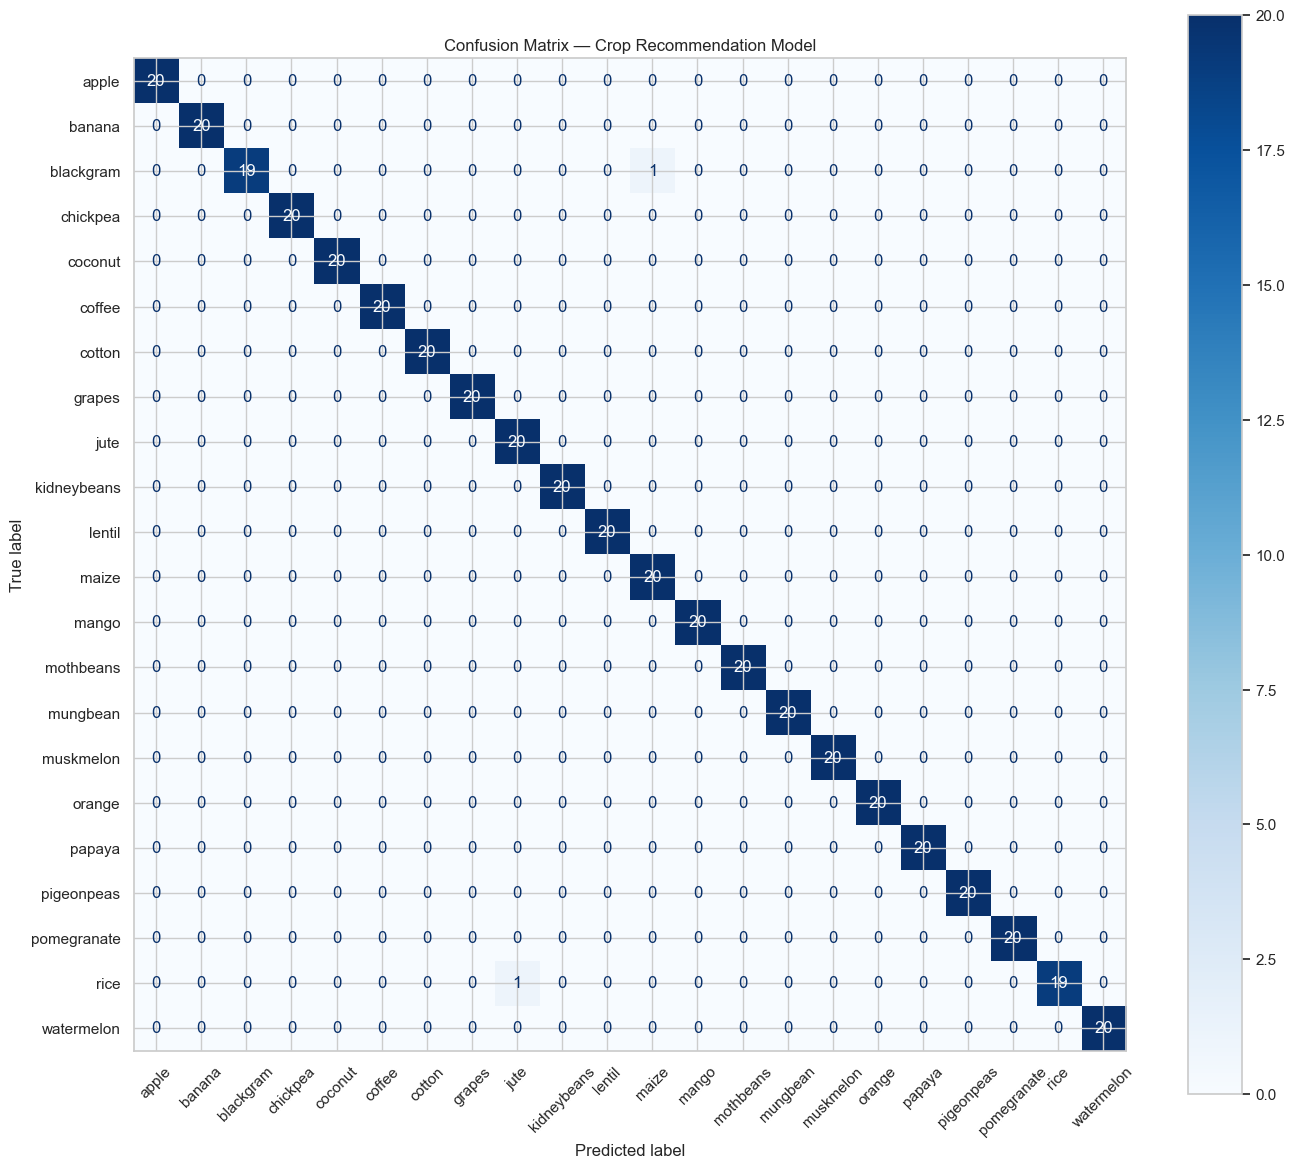

In [22]:
fig, ax = plt.subplots(figsize=(14, 12))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues')
plt.title("Confusion Matrix — Crop Recommendation Model")
plt.tight_layout()
plt.show()

### 6.4 Feature Importance

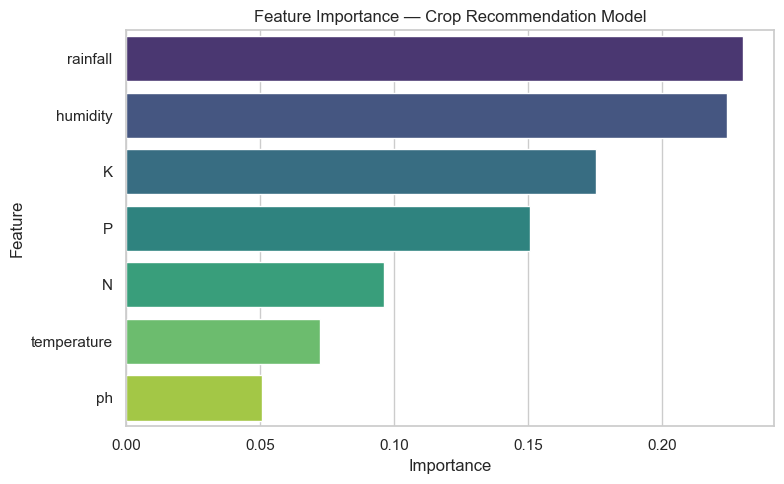

    Feature  Importance
   rainfall    0.230184
   humidity    0.224227
          K    0.175393
          P    0.150850
          N    0.096363
temperature    0.072375
         ph    0.050608


In [23]:
importances = pipeline.named_steps['rf'].feature_importances_
imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=imp_df, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importance — Crop Recommendation Model")
plt.tight_layout()
plt.show()

print(imp_df.to_string(index=False))

## 7. Save Model & Encoder

In [ ]:
import os
save_dir = "models"
os.makedirs(save_dir, exist_ok=True)

joblib.dump(pipeline, os.path.join(save_dir, "crop_model.pkl"))
joblib.dump(le,       os.path.join(save_dir, "crop_label_encoder.pkl"))

print("Saved:")
print(f"  {save_dir}/crop_model.pkl")
print(f"  {save_dir}/crop_label_encoder.pkl")

## 8. Quick Prediction Test

In [24]:
sample = {
    "N": 90,            # manual UI input
    "P": 42,            # manual UI input
    "K": 43,            # manual UI input
    "temperature": 20.8,   # DHT22 sensor
    "humidity": 82.0,      # DHT22 sensor
    "ph": 6.5,             # pH sensor
    "rainfall": 202.9      # manual UI input
}

X_sample = [list(sample.values())]
pred_enc   = pipeline.predict(X_sample)[0]
proba      = pipeline.predict_proba(X_sample)[0]
crop_name  = le.inverse_transform([pred_enc])[0]
confidence = round(proba[pred_enc] * 100, 2)

print(f"Recommended Crop : {crop_name}")
print(f"Confidence       : {confidence}%")

Recommended Crop : rice
Confidence       : 90.0%
